# 07b — Person-Days Diagnostic: Tmin / TN90p (warm nights)

Mirrors notebook 07 but uses **daily minimum temperature (Tmin)** and the **TN90p** threshold (calendar-day 90th percentile of Tmin) instead of Tmax / TX90p.

Minimum temperature governs overnight recovery — nights where temperature stays high prevent physiological recovery and are independently associated with excess heat mortality.  TN90p warm nights are an ETCCDI index and a recognised heat health metric.

The absolute reference is **20 °C** — the ETCCDI "tropical night" definition (Tmin > 20 °C).

**Prerequisites:** `01b_data_acquisition_tmin` (tmin NetCDF files), plus the population grids and neighbourhood boundaries from notebook 07.

## Setup

In [10]:
import importlib, utils.heat                                                                                                                                                                                                                                                
importlib.reload(utils.heat)

<module 'utils.heat' from '/Users/martynclark/heatInsights-notebooks/heat_threshold_analysis/utils/heat.py'>

In [11]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import xarray as xr
from scipy.stats import spearmanr

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES, load_city_tmin, load_tn90p_threshold, load_neighbourhood_boundaries,
    compute_absolute_heat_days, compute_person_days_map,
    aggregate_to_neighbourhoods, aggregate_person_days_to_neighbourhoods,
)

DATA_DIR      = 'data'
DIAG_YEAR     = 2020
ABS_THRESHOLD = 20.0   # tropical nights: Tmin > 20 °C  (ETCCDI definition)
PERCENTILE    = 90
CITY_KEYS     = ['salvador', 'teresina', 'caceres']

cities = {}
for c in CITY_KEYS:
    da = load_city_tmin(c, DATA_DIR)
    da.attrs['units'] = 'degC'
    cities[c] = da

thresholds = {c: load_tn90p_threshold(c, DATA_DIR) for c in CITY_KEYS}

gdfs = {c: load_neighbourhood_boundaries(c, DATA_DIR) for c in CITY_KEYS}

def load_pop_grid(city, year):
    return xr.open_dataset(f'{DATA_DIR}/{city}_pop_1km_{year}.nc')['population']

def count_doy_exceedances(da, thresh_doy):
    aligned = thresh_doy.sel(dayofyear=da.time.dt.dayofyear)
    return (da > aligned).resample(time='YS').sum(dim='time')

# Pre-compute TN90p annual warm-night counts
tn_annual = {c: {} for c in CITY_KEYS}
for c in CITY_KEYS:
    tn_annual[c][PERCENTILE] = count_doy_exceedances(
        cities[c], thresholds[c].sel(percentile=PERCENTILE)
    )

salvador: shape {'time': 6496, 'lat': 48, 'lon': 67}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6496, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6496, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
salvador TN90p threshold: shape {'percentile': 2, 'lat': 48, 'lon': 67, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 17.4–29.7 °C
teresina TN90p threshold: shape {'percentile': 2, 'lat': 67, 'lon': 78, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 22.3–27.7 °C
caceres TN90p threshold: shape {'percentile': 2, 'lat': 89, 'lon': 89, 'dayofyear': 365}  window=5  percentiles=[90, 95]  range 17.9–27.5 °C
Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg
Loaded 112 neighbourhoods from cache: data/geobr_teresina_neighbourhoods_2010.gpkg
Loaded 43 neighbourhoods from cache: data/geobr_caceres_neighbourhoods_2010.gpkg


In [12]:
def build_nbhd_table(city_key, year):
    """Per-neighbourhood dataframe: population, warm nights, person-days, ranks."""
    da       = cities[city_key]
    gdf      = gdfs[city_key]
    pop_grid = load_pop_grid(city_key, year)

    abs_hd = compute_absolute_heat_days(da, year, ABS_THRESHOLD)
    tn_hd  = (
        tn_annual[city_key][PERCENTILE]
        .isel(time=(tn_annual[city_key][PERCENTILE].time.dt.year == year))
        .squeeze('time')
    )

    pop_nbhd    = aggregate_person_days_to_neighbourhoods(pop_grid, gdf, col='population')
    abs_hd_nbhd = aggregate_to_neighbourhoods(abs_hd, gdf, col='abs_hd')
    tn_hd_nbhd  = aggregate_to_neighbourhoods(tn_hd,  gdf, col='tn90p_hd')
    abs_pd_nbhd = aggregate_person_days_to_neighbourhoods(
                      compute_person_days_map(abs_hd, pop_grid), gdf, col='abs_pd')
    tn_pd_nbhd  = aggregate_person_days_to_neighbourhoods(
                      compute_person_days_map(tn_hd,  pop_grid), gdf, col='tn90p_pd')

    df = gdf[['name']].copy()
    df['population'] = pop_nbhd['population'].values
    df['abs_hd']     = abs_hd_nbhd['abs_hd'].values
    df['tn90p_hd']   = tn_hd_nbhd['tn90p_hd'].values
    df['abs_pd']     = abs_pd_nbhd['abs_pd'].values
    df['tn90p_pd']   = tn_pd_nbhd['tn90p_pd'].values
    for col in ['population', 'abs_hd', 'tn90p_hd', 'abs_pd', 'tn90p_pd']:
        df[f'rank_{col}'] = df[col].rank(ascending=False, method='min').astype(int)
    return df.dropna().reset_index(drop=True)

tables = {c: build_nbhd_table(c, DIAG_YEAR) for c in CITY_KEYS}

## Threshold choice: absolute 20 °C (tropical nights) vs TN90p

The 20 °C absolute threshold for Tmin defines a "tropical night" — a night when minimum temperature never falls below 20 °C, giving the body no cool recovery window.  Like the 30 °C Tmax threshold in notebook 07, it may saturate in the hottest cities where almost every night qualifies.

TN90p adapts to local conditions: a warm night is flagged only when Tmin exceeds the local 90th percentile for that calendar day.

The table below shows TN90p threshold temperatures and warm-night day ranges.  The maps compare the spatial pattern from each approach across neighbourhoods.

**Note:** unlike Tmax, Tmin in these tropical Brazilian cities is expected to be less spatially variable within a city — UHI effects on overnight temperature tend to be more uniform than daytime peaks.  The CV column makes this explicit.

,Absolute threshold (°C),TN90p mean (°C),TN90p min (°C),TN90p max (°C),Abs hd range (nights),Abs hd CV,TN90p hd range (nights),TN90p hd CV
City,,,,,,,,
"Salvador, Brazil",20,23.6,17.4,28.4,0–284,0.43,0–25,0.44
"Teresina, Brazil",20,24.4,22.3,26.6,321–361,0.01,8–30,0.32
"Cáceres, Brazil",20,23.1,17.9,26.2,268–278,0.01,45–62,0.07


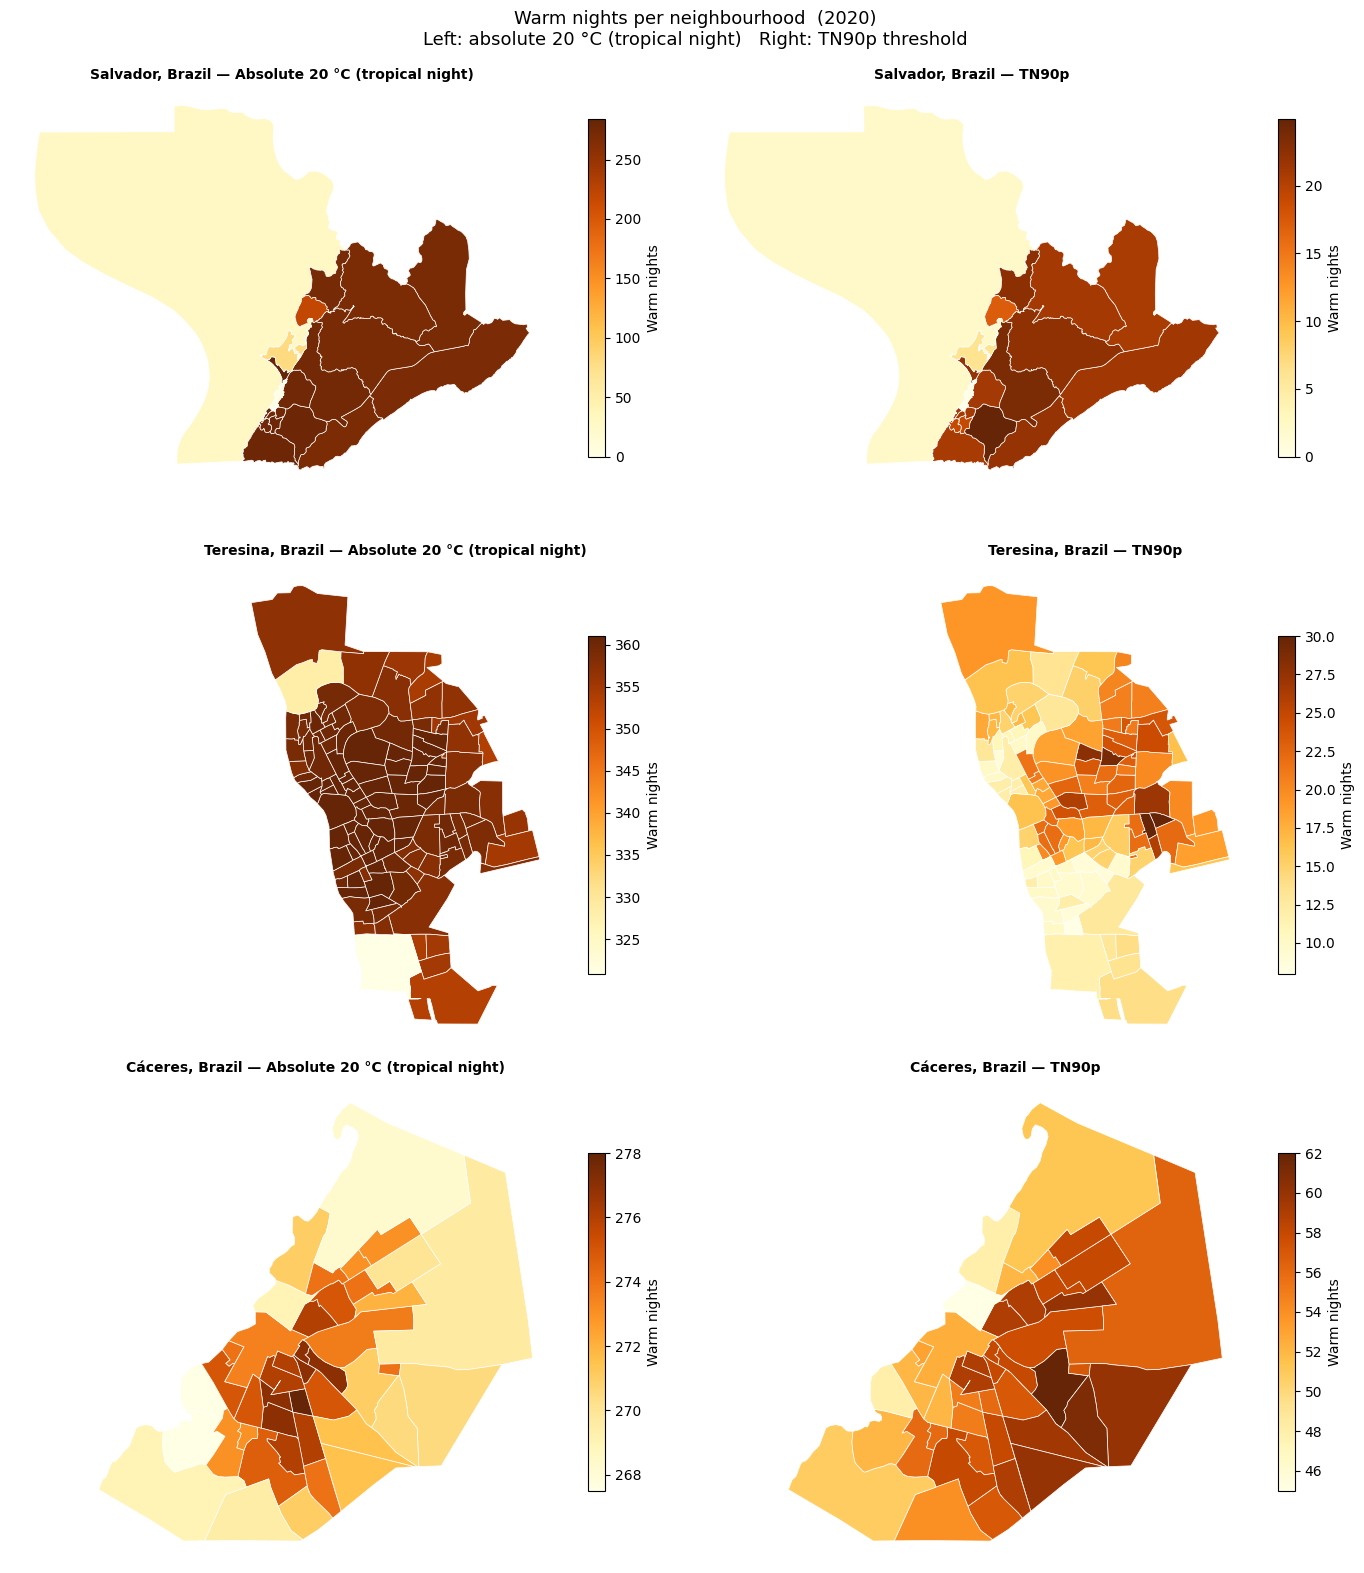

In [13]:
import matplotlib.colors as mcolors

# ---- Table: threshold temperatures and warm-night ranges ---------------------
thresh_rows = []
for c in CITY_KEYS:
    t90 = thresholds[c].sel(percentile=90)
    df  = tables[c]
    thresh_rows.append({
        'City':                    CITIES[c]['label'],
        'Absolute threshold (°C)': ABS_THRESHOLD,
        'TN90p mean (°C)':         float(t90.mean()),
        'TN90p min (°C)':          float(t90.min()),
        'TN90p max (°C)':          float(t90.max()),
        'Abs hd range (nights)':   f"{df['abs_hd'].min():.0f}–{df['abs_hd'].max():.0f}",
        'Abs hd CV':               df['abs_hd'].std() / df['abs_hd'].mean() if df['abs_hd'].mean() > 0 else 0,
        'TN90p hd range (nights)': f"{df['tn90p_hd'].min():.0f}–{df['tn90p_hd'].max():.0f}",
        'TN90p hd CV':             df['tn90p_hd'].std() / df['tn90p_hd'].mean() if df['tn90p_hd'].mean() > 0 else 0,
    })

thresh_df = pd.DataFrame(thresh_rows).set_index('City')
fmt = {
    'Absolute threshold (°C)': '{:.0f}',
    'TN90p mean (°C)': '{:.1f}', 'TN90p min (°C)': '{:.1f}', 'TN90p max (°C)': '{:.1f}',
    'Abs hd CV': '{:.2f}', 'TN90p hd CV': '{:.2f}',
    'Abs hd range (nights)': '{}', 'TN90p hd range (nights)': '{}',
}

table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th', 'props': 'text-align:center; white-space:nowrap; font-size:0.85em;'},
    {'selector': 'td', 'props': 'text-align:center; font-size:0.85em;'},
]

display(
    thresh_df.style.format(fmt)
    .background_gradient(subset=['Abs hd CV', 'TN90p hd CV'], cmap='RdYlGn', axis=None)
    .set_caption(
        f'Threshold comparison ({DIAG_YEAR})  |  '
        'CV near 0 = no spatial variation = threshold is not useful for neighbourhood ranking'
    )
    .set_table_styles(table_styles)
)

# ---- Maps: warm nights by neighbourhood, both thresholds --------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle(
    f'Warm nights per neighbourhood  ({DIAG_YEAR})\n'
    'Left: absolute 20 °C (tropical night)   Right: TN90p threshold',
    fontsize=13,
)

for row, c in enumerate(CITY_KEYS):
    df    = tables[c]
    label = CITIES[c]['label']

    plot_gdf = gdfs[c].merge(
        df[['name', 'abs_hd', 'tn90p_hd', 'population']],
        on='name', how='left',
    )

    for col, (col_name, title_suffix, cmap) in enumerate([
        ('abs_hd',   'Absolute 20 °C (tropical night)', 'YlOrBr'),
        ('tn90p_hd', 'TN90p',                           'YlOrBr'),
    ]):
        ax = axes[row][col]
        plot_gdf.plot(
            column=col_name, ax=ax, cmap=cmap,
            legend=True,
            legend_kwds={'label': 'Warm nights', 'shrink': 0.7},
            edgecolor='white', linewidth=0.5, missing_kwds={'color': 'lightgrey'},
        )
        ax.set_title(f'{label} — {title_suffix}', fontsize=10, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

## Finding 1 — Person-day rankings are driven by population, not heat days

**What this test shows:** if person-days captured both heat *and* population variation
equally, neighbourhood ranks would sit somewhere between a pure population ranking and
a pure heat-day ranking.  Instead, across all three cities and both threshold
definitions, person-day rank is almost perfectly explained by population rank alone.

The figure below plots population rank against person-day rank for each city.
A perfect diagonal means person-days = population × constant — the heat-day
dimension is adding nothing.

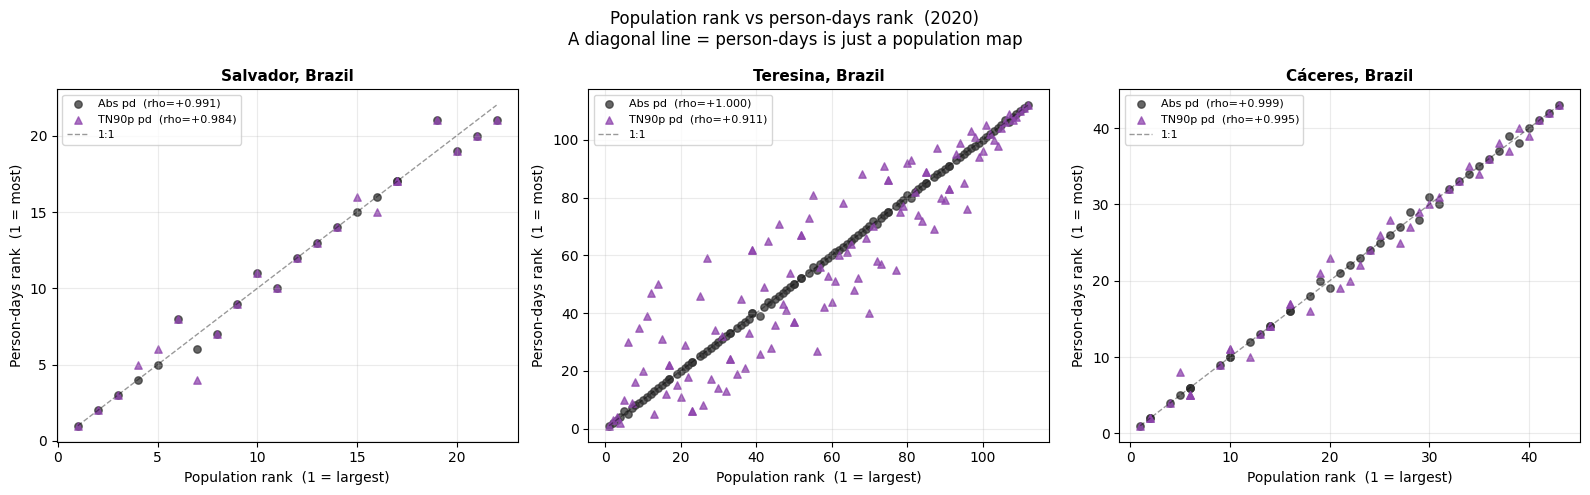

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Population rank vs person-days rank  ({DIAG_YEAR})\n'
    'A diagonal line = person-days is just a population map',
    fontsize=12,
)

for ax, c in zip(axes, CITY_KEYS):
    df    = tables[c]
    n     = len(df)
    label = CITIES[c]['label']

    rho_abs, _ = spearmanr(df['rank_population'], df['rank_abs_pd'])
    rho_tn,  _ = spearmanr(df['rank_population'], df['rank_tn90p_pd'])

    ax.scatter(df['rank_population'], df['rank_abs_pd'],
               s=28, alpha=0.75, color='#333333', label=f'Abs pd  (rho={rho_abs:+.3f})')
    ax.scatter(df['rank_population'], df['rank_tn90p_pd'],
               s=28, alpha=0.75, color='#8e44ad', marker='^',
               label=f'TN90p pd  (rho={rho_tn:+.3f})')
    ax.plot([1, n], [1, n], 'k--', linewidth=1, alpha=0.4, label='1:1')

    ax.set_xlabel('Population rank  (1 = largest)', fontsize=10)
    ax.set_ylabel('Person-days rank  (1 = most)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Summary statistics — all three cities

The table below captures the key numbers behind the finding.  The **CV columns**
compare how much each variable varies across neighbourhoods relative to its mean —
a higher CV means that variable has more influence on neighbourhood-level differences.
The **Spearman ρ columns** measure how strongly two rankings agree (1 = identical,
0 = unrelated).

Read across a row: if population CV >> heat-day CV, population dominates the product.
If ρ(pop, person-days) ≈ 1, the person-day map is a population map.

In [15]:
rows = []
for c in CITY_KEYS:
    df = tables[c]
    rho_pop_abs_pd,  _ = spearmanr(df['population'], df['abs_pd'])
    rho_pop_tn_pd,   _ = spearmanr(df['population'], df['tn90p_pd'])
    rho_abshd_abspd, _ = spearmanr(df['abs_hd'],     df['abs_pd'])
    rho_tnhd_tnpd,   _ = spearmanr(df['tn90p_hd'],   df['tn90p_pd'])
    rho_abspd_tnpd,  _ = spearmanr(df['abs_pd'],      df['tn90p_pd'])
    rho_abshd_tnhd,  _ = spearmanr(df['abs_hd'],      df['tn90p_hd'])

    rows.append({
        'City':             CITIES[c]['label'],
        'CV: population':   df['population'].std() / df['population'].mean(),
        'CV: abs hd':       df['abs_hd'].std()     / df['abs_hd'].mean() if df['abs_hd'].mean() > 0 else np.nan,
        'CV: TN90p hd':     df['tn90p_hd'].std()   / df['tn90p_hd'].mean() if df['tn90p_hd'].mean() > 0 else np.nan,
        'Abs hd range':     f"{df['abs_hd'].min():.0f}–{df['abs_hd'].max():.0f} nights",
        'TN90p hd range':   f"{df['tn90p_hd'].min():.0f}–{df['tn90p_hd'].max():.0f} nights",
        '\u03c1 pop vs abs pd':       rho_pop_abs_pd,
        '\u03c1 pop vs TN90p pd':     rho_pop_tn_pd,
        '\u03c1 abs hd vs abs pd':    rho_abshd_abspd,
        '\u03c1 TN90p hd vs TN90p pd': rho_tnhd_tnpd,
        '\u03c1 abs pd vs TN90p pd':  rho_abspd_tnpd,
        '\u03c1 abs hd vs TN90p hd':  rho_abshd_tnhd,
    })

summary = pd.DataFrame(rows).set_index('City')

cv_cols  = ['CV: population', 'CV: abs hd', 'CV: TN90p hd']
rho_cols = [
    '\u03c1 pop vs abs pd', '\u03c1 pop vs TN90p pd',
    '\u03c1 abs hd vs abs pd', '\u03c1 TN90p hd vs TN90p pd',
    '\u03c1 abs pd vs TN90p pd', '\u03c1 abs hd vs TN90p hd',
]

fmt = {c: '{:.3f}' for c in cv_cols + rho_cols}
fmt['Abs hd range']   = '{}'
fmt['TN90p hd range'] = '{}'

display(
    summary.style
    .format(fmt)
    .background_gradient(subset=cv_cols, cmap='YlOrRd', axis=None)
    .background_gradient(subset=rho_cols, cmap='RdYlGn', axis=None, vmin=-1, vmax=1)
    .set_caption(
        f'Neighbourhood-level summary  ({DIAG_YEAR})  |  '
        'CV = coefficient of variation  |  \u03c1 = Spearman rank correlation'
    )
    .set_table_styles(table_styles)
)

,CV: population,CV: abs hd,CV: TN90p hd,Abs hd range,TN90p hd range,ρ pop vs abs pd,ρ pop vs TN90p pd,ρ abs hd vs abs pd,ρ TN90p hd vs TN90p pd,ρ abs pd vs TN90p pd,ρ abs hd vs TN90p hd
City,,,,,,,,,,,
"Salvador, Brazil",1.041,0.434,0.440,0–284 nights,0–25 nights,0.991,0.984,0.128,0.634,0.995,0.571
"Teresina, Brazil",0.878,0.014,0.320,321–361 nights,8–30 nights,1.000,0.911,0.081,0.391,0.912,0.204
"Cáceres, Brazil",0.506,0.011,0.067,268–278 nights,45–62 nights,0.999,0.995,0.624,0.090,0.994,0.222


## Finding 2 — Three distinct mechanisms, one shared result

The population-dominance pattern arises for different reasons in each city.
The figure below makes each mechanism visible.

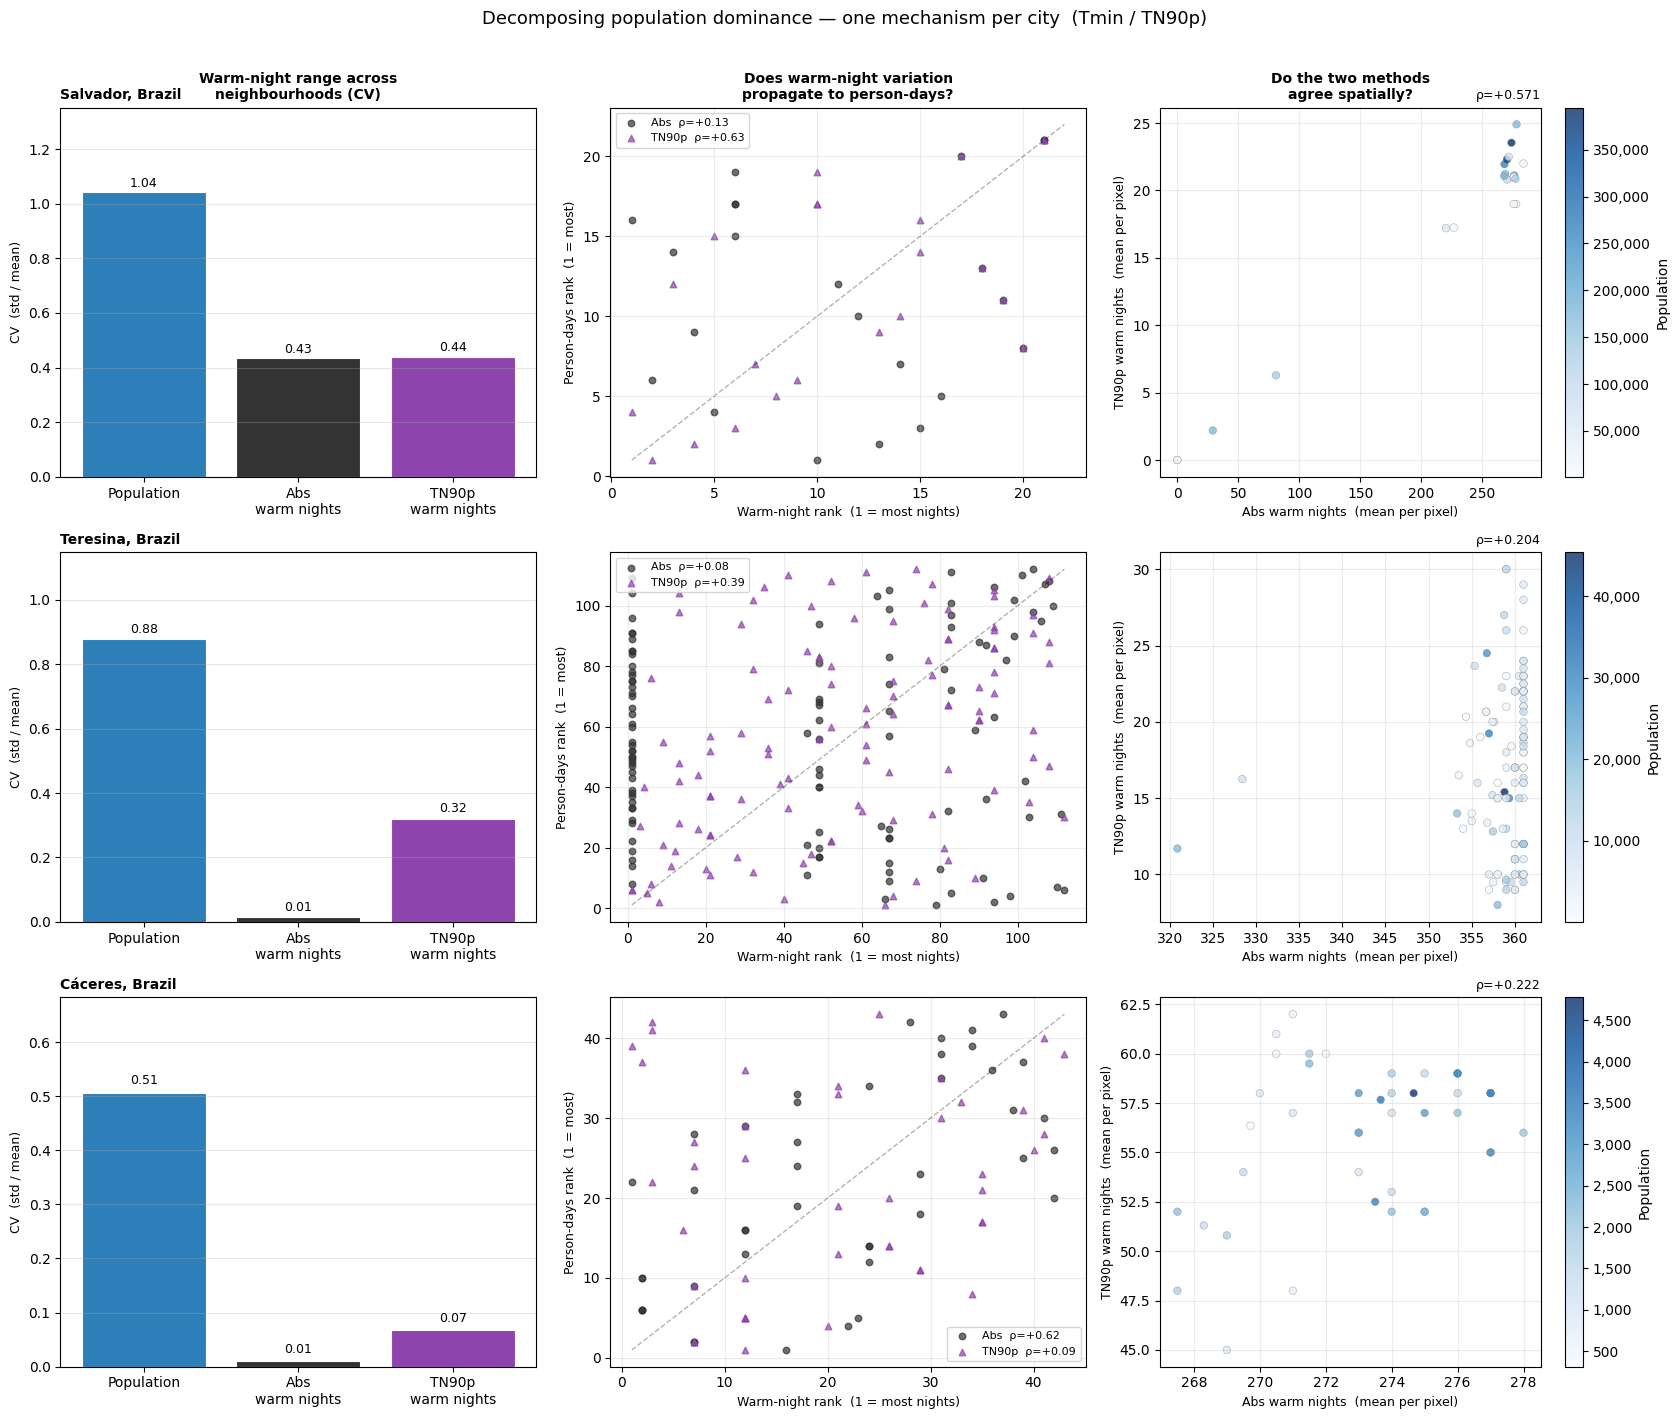

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(17, 14))
fig.suptitle(
    'Decomposing population dominance — one mechanism per city  (Tmin / TN90p)',
    fontsize=13, y=1.01,
)

panel_titles = [
    'Warm-night range across\nneighbourhoods (CV)',
    'Does warm-night variation\npropagate to person-days?',
    'Do the two methods\nagree spatially?',
]
for ax, t in zip(axes[0], panel_titles):
    ax.set_title(t, fontsize=10, fontweight='bold')

for row, c in enumerate(CITY_KEYS):
    df    = tables[c]
    label = CITIES[c]['label']

    # ---- Panel 1: CV bar chart -----------------------------------------------
    ax = axes[row][0]
    cv_vals = [
        df['population'].std() / df['population'].mean(),
        df['abs_hd'].std()     / df['abs_hd'].mean()     if df['abs_hd'].mean()   > 0 else 0,
        df['tn90p_hd'].std()   / df['tn90p_hd'].mean()   if df['tn90p_hd'].mean() > 0 else 0,
    ]
    bars = ax.bar(['Population', 'Abs\nwarm nights', 'TN90p\nwarm nights'],
                  cv_vals,
                  color=['#2c7fb8', '#333333', '#8e44ad'],
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, cv_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.2f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('CV  (std / mean)', fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold', loc='left')
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_ylim(0, max(cv_vals) * 1.25 + 0.05)

    # ---- Panel 2: warm-night rank vs person-day rank -------------------------
    ax = axes[row][1]
    n  = len(df)
    rho_abs, _ = spearmanr(df['rank_abs_hd'],   df['rank_abs_pd'])
    rho_tn,  _ = spearmanr(df['rank_tn90p_hd'], df['rank_tn90p_pd'])
    ax.scatter(df['rank_abs_hd'],   df['rank_abs_pd'],
               s=22, alpha=0.7, color='#333333',
               label=f'Abs  \u03c1={rho_abs:+.2f}')
    ax.scatter(df['rank_tn90p_hd'], df['rank_tn90p_pd'],
               s=22, alpha=0.7, color='#8e44ad', marker='^',
               label=f'TN90p  \u03c1={rho_tn:+.2f}')
    ax.plot([1, n], [1, n], 'k--', lw=1, alpha=0.3)
    ax.set_xlabel('Warm-night rank  (1 = most nights)', fontsize=9)
    ax.set_ylabel('Person-days rank  (1 = most)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

    # ---- Panel 3: abs hd vs tn90p hd ----------------------------------------
    ax = axes[row][2]
    rho_hd, _ = spearmanr(df['abs_hd'], df['tn90p_hd'])
    sc = ax.scatter(df['abs_hd'], df['tn90p_hd'],
                    c=df['population'], cmap='Blues',
                    s=30, alpha=0.8, edgecolors='grey', linewidth=0.3)
    plt.colorbar(sc, ax=ax, label='Population', format=mticker.FuncFormatter(
        lambda x, _: f'{x:,.0f}'))
    ax.set_xlabel('Abs warm nights  (mean per pixel)', fontsize=9)
    ax.set_ylabel('TN90p warm nights  (mean per pixel)', fontsize=9)
    ax.set_title(f'\u03c1={rho_hd:+.3f}', fontsize=9, loc='right')
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Interpretation

### What the panels show

**Column 1 — CV comparison.**  The bar height tells you how much each variable varies *across neighbourhoods* relative to its mean.  Where population CV is much taller than warm-night CV, population is the only driver of neighbourhood differences in the person-nights product.

**Column 2 — Does warm-night variation propagate to person-nights?**  If warm nights controlled person-night rankings, the scatter would lie on the diagonal.  A flat cloud means warm-night differences between neighbourhoods have been erased by population.

**Column 3 — Do the two methods agree spatially?**  Points coloured by population.  A tight positive slope means the absolute 20 °C threshold and TN90p flag the same neighbourhoods.  A flat or negative slope means threshold choice changes which neighbourhoods look warm — though population dominance may make this invisible in the person-nights product regardless.

In [17]:
from IPython.display import Markdown

_SAT  = 0.05   # CV below this = saturated (no useful spatial signal)
_ANTI = -0.20  # ρ below this = spatially anti-correlated

def _mechanism_text(c):
    df    = tables[c]
    label = CITIES[c]['label']

    cv_pop = df['population'].std() / df['population'].mean()
    cv_abs = df['abs_hd'].std()    / df['abs_hd'].mean()    if df['abs_hd'].mean()    > 0 else 0.0
    cv_tn  = df['tn90p_hd'].std()  / df['tn90p_hd'].mean()  if df['tn90p_hd'].mean()  > 0 else 0.0

    rho_pop_abs, _ = spearmanr(df['population'], df['abs_pd'])
    rho_pop_tn,  _ = spearmanr(df['population'], df['tn90p_pd'])
    rho_abs_tn,  _ = spearmanr(df['abs_hd'],     df['tn90p_hd'])

    abs_lo, abs_hi = df['abs_hd'].min(), df['abs_hd'].max()
    tn_lo,  tn_hi  = df['tn90p_hd'].min(), df['tn90p_hd'].max()

    parts = [f'**{label}**']

    # Absolute threshold sentence
    if cv_abs < _SAT:
        parts.append(
            f'The 20 °C absolute threshold is **saturated**: warm-night counts range only '
            f'{abs_lo:.0f}–{abs_hi:.0f} nights across neighbourhoods (CV = {cv_abs:.2f}), '
            f'carrying no spatial signal. Person-nights ≈ population × constant '
            f'(ρ(pop, abs pd) = {rho_pop_abs:+.3f}).'
        )
    else:
        ratio = cv_pop / cv_abs if cv_abs > 0 else float('inf')
        parts.append(
            f'The absolute 20 °C threshold shows spatial variation '
            f'(range {abs_lo:.0f}–{abs_hi:.0f} nights, CV = {cv_abs:.2f}), '
            f'but population CV = {cv_pop:.2f} is {ratio:.1f}× larger — '
            f'person-nights remain population-driven (ρ(pop, abs pd) = {rho_pop_abs:+.3f}).'
        )

    # TN90p sentence
    if cv_tn < _SAT:
        parts.append(
            f'TN90p warm nights are similarly near-uniform across neighbourhoods '
            f'(range {tn_lo:.0f}–{tn_hi:.0f} nights, CV = {cv_tn:.2f}); '
            f'person-nights ≈ population (ρ(pop, TN90p pd) = {rho_pop_tn:+.3f}).'
        )
    else:
        ratio_tn = cv_pop / cv_tn if cv_tn > 0 else float('inf')
        parts.append(
            f'TN90p warm nights show more variation (range {tn_lo:.0f}–{tn_hi:.0f} nights, '
            f'CV = {cv_tn:.2f}), but population CV is still {ratio_tn:.1f}× larger '
            f'(ρ(pop, TN90p pd) = {rho_pop_tn:+.3f}).'
        )

    # Method agreement sentence
    if rho_abs_tn < _ANTI:
        parts.append(
            f'The two methods are **spatially anti-correlated** (ρ(abs, TN90p) = {rho_abs_tn:+.3f}): '
            f'neighbourhoods with the most tropical nights have among the fewest TN90p exceedances, '
            f'because persistently warm areas have a high baseline and rarely exceed their own 90th percentile.'
        )
    elif rho_abs_tn > 0.7:
        parts.append(
            f'Both methods agree spatially (ρ(abs, TN90p) = {rho_abs_tn:+.3f}): '
            f'the same neighbourhoods are warm under both the absolute and relative definitions.'
        )
    else:
        parts.append(
            f'The two methods show moderate spatial agreement (ρ(abs, TN90p) = {rho_abs_tn:+.3f}).'
        )

    return '\n\n'.join(parts)


# --- Overall summary ----------------------------------------------------------
rho_vals = [spearmanr(tables[c]['population'], tables[c]['tn90p_pd'])[0] for c in CITY_KEYS]
avg_rho  = float(np.mean(rho_vals))

if avg_rho > 0.90:
    conclusion = (
        f'Across all three cities, TN90p person-nights correlate with population at '
        f'ρ = {avg_rho:.3f} on average — confirming that person-nights is effectively a '
        f'population map at 1 km intra-city resolution for Tmin. '
        f'This is likely **stronger than for Tmax** (notebook 07), consistent with '
        f'overnight temperature being more spatially uniform than daytime maxima at this scale.'
    )
elif avg_rho > 0.70:
    conclusion = (
        f'Across all three cities, TN90p person-nights correlate with population at '
        f'ρ = {avg_rho:.3f} on average. There is partial decoupling in at least one city, '
        f'suggesting some spatial structure in overnight temperature at neighbourhood scale.'
    )
else:
    conclusion = (
        f'Across all three cities, TN90p person-nights correlate with population at '
        f'ρ = {avg_rho:.3f} on average — a weaker relationship than for Tmax (notebook 07), '
        f'indicating that overnight temperature has more meaningful spatial variation within these cities.'
    )

city_block = '\n\n---\n\n'.join(_mechanism_text(c) for c in CITY_KEYS)

display(Markdown(f"""
### City-specific findings

{city_block}

---

### What this means for the Tmin analysis

{conclusion}

**Cross-notebook comparison:** place this notebook's quadrant (TN90p warm nights × population)
alongside notebook 07's quadrant (TX90p heat days × population) to identify neighbourhoods
that are **Hot + Dense in both**. Those face both daytime heat exposure and warm-night sleep
disruption — the strongest candidates for heat health intervention.
"""))


### City-specific findings

**Salvador, Brazil**

The absolute 20 °C threshold shows spatial variation (range 0–284 nights, CV = 0.43), but population CV = 1.04 is 2.4× larger — person-nights remain population-driven (ρ(pop, abs pd) = +0.991).

TN90p warm nights show more variation (range 0–25 nights, CV = 0.44), but population CV is still 2.4× larger (ρ(pop, TN90p pd) = +0.984).

The two methods show moderate spatial agreement (ρ(abs, TN90p) = +0.571).

---

**Teresina, Brazil**

The 20 °C absolute threshold is **saturated**: warm-night counts range only 321–361 nights across neighbourhoods (CV = 0.01), carrying no spatial signal. Person-nights ≈ population × constant (ρ(pop, abs pd) = +1.000).

TN90p warm nights show more variation (range 8–30 nights, CV = 0.32), but population CV is still 2.7× larger (ρ(pop, TN90p pd) = +0.911).

The two methods show moderate spatial agreement (ρ(abs, TN90p) = +0.204).

---

**Cáceres, Brazil**

The 20 °C absolute threshold is **saturated**: warm-night counts range only 268–278 nights across neighbourhoods (CV = 0.01), carrying no spatial signal. Person-nights ≈ population × constant (ρ(pop, abs pd) = +0.999).

TN90p warm nights show more variation (range 45–62 nights, CV = 0.07), but population CV is still 7.5× larger (ρ(pop, TN90p pd) = +0.995).

The two methods show moderate spatial agreement (ρ(abs, TN90p) = +0.222).

---

### What this means for the Tmin analysis

Across all three cities, TN90p person-nights correlate with population at ρ = 0.963 on average — confirming that person-nights is effectively a population map at 1 km intra-city resolution for Tmin. This is likely **stronger than for Tmax** (notebook 07), consistent with overnight temperature being more spatially uniform than daytime maxima at this scale.

**Cross-notebook comparison:** place this notebook's quadrant (TN90p warm nights × population)
alongside notebook 07's quadrant (TX90p heat days × population) to identify neighbourhoods
that are **Hot + Dense in both**. Those face both daytime heat exposure and warm-night sleep
disruption — the strongest candidates for heat health intervention.


## Recommended visualisation approach

**In the tool:** colour neighbourhoods by person-days (total heat burden).  This correctly answers "where does aggregate exposure accumulate?" and is the right metric for prioritising intervention by impact — more people benefitting from a cooling intervention always counts for more.

**Alongside the tool:** a quadrant plot separates the two dimensions so that neighbourhoods which are hot but small (high heat days, low population) are still visible and actionable — they may be lower-impact but higher-urgency for heat health response.

Quadrant boundaries are set at the **city median** for each dimension.  This is a relative classification within each city, consistent with the TX90p logic of relative rather than absolute thresholds.

| Quadrant | Interpretation | Suggested action |
|---|---|---|
| **Hot + Dense** | Highest aggregate burden; greatest intervention impact | Priority for cooling infrastructure |
| **Hot + Sparse** | Elevated heat risk per person; fewer beneficiaries | Heat health surveillance, early warning |
| **Cool + Dense** | Large population, lower heat exposure | Monitor; lower immediate heat priority |
| **Cool + Sparse** | Low burden, low population | Baseline |

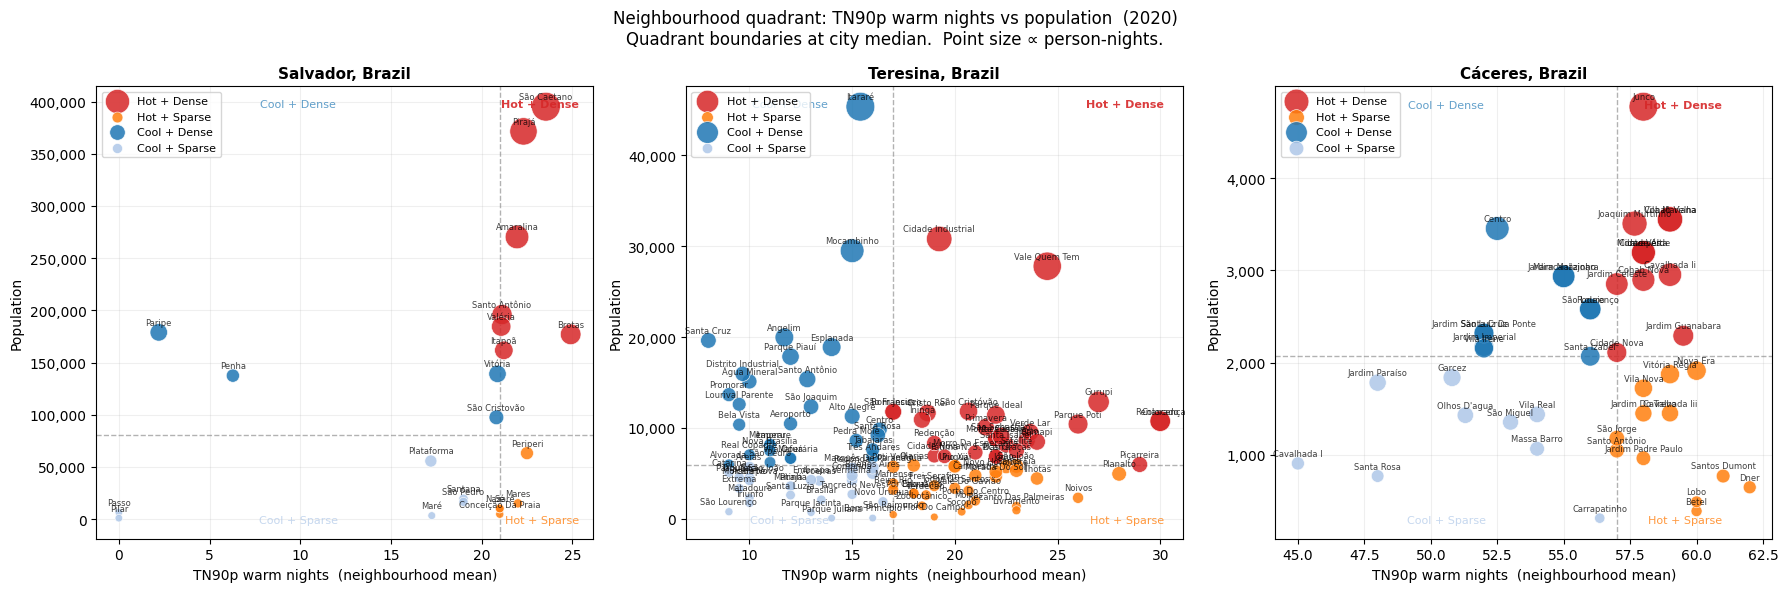


Neighbourhoods per quadrant  (2020, TN90p)

--- Salvador, Brazil ---


,N neighbourhoods,Total population,Mean warm nights,Total person-nights
quadrant,,,,
Hot + Dense,7,"1,756,092",22.3,"39,543,708"
Hot + Sparse,5,"103,322",21.5,"2,207,662"
Cool + Dense,4,"552,988",12.5,"9,291,490"
Cool + Sparse,6,"102,425",12.1,"1,783,704"


--- Teresina, Brazil ---


,N neighbourhoods,Total population,Mean warm nights,Total person-nights
quadrant,,,,
Hot + Dense,28,"300,553",22.4,"6,674,674"
Hot + Sparse,29,"99,661",20.6,"2,065,375"
Cool + Dense,28,"366,399",12.3,"4,616,228"
Cool + Sparse,27,"91,402",12.4,"1,124,531"


--- Cáceres, Brazil ---


,N neighbourhoods,Total population,Mean warm nights,Total person-nights
quadrant,,,,
Hot + Dense,12,"38,075",58.2,"2,213,722"
Hot + Sparse,12,"13,894",59.1,"815,482"
Cool + Dense,10,"25,522",53.9,"1,376,676"
Cool + Sparse,9,"10,897",51.2,"558,589"


In [18]:
QUADRANT_COLORS = {
    'Hot + Dense':   '#d62728',
    'Hot + Sparse':  '#ff7f0e',
    'Cool + Dense':  '#1f77b4',
    'Cool + Sparse': '#aec7e8',
}

def assign_quadrant(hd, pop, hd_med, pop_med):
    hot   = hd  >= hd_med
    dense = pop >= pop_med
    if hot and dense:   return 'Hot + Dense'
    if hot:             return 'Hot + Sparse'
    if dense:           return 'Cool + Dense'
    return 'Cool + Sparse'

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'Neighbourhood quadrant: TN90p warm nights vs population  ({DIAG_YEAR})\n'
    'Quadrant boundaries at city median.  Point size ∝ person-nights.',
    fontsize=12,
)

for ax, c in zip(axes, CITY_KEYS):
    df      = tables[c].copy()
    label   = CITIES[c]['label']
    hd_med  = df['tn90p_hd'].median()
    pop_med = df['population'].median()

    df['quadrant'] = df.apply(
        lambda r: assign_quadrant(r['tn90p_hd'], r['population'], hd_med, pop_med), axis=1
    )

    pd_norm = (df['tn90p_pd'] / df['tn90p_pd'].max()) * 400 + 30

    for q, color in QUADRANT_COLORS.items():
        mask = df['quadrant'] == q
        ax.scatter(
            df.loc[mask, 'tn90p_hd'],
            df.loc[mask, 'population'],
            s=pd_norm[mask], color=color, alpha=0.85,
            edgecolors='white', linewidth=0.5, label=q, zorder=3,
        )

    for _, row in df.iterrows():
        ax.annotate(
            row['name'], (row['tn90p_hd'], row['population']),
            fontsize=6, alpha=0.75, ha='center', va='bottom',
            xytext=(0, 4), textcoords='offset points',
        )

    ax.axvline(hd_med,  color='grey', linewidth=1, linestyle='--', alpha=0.6)
    ax.axhline(pop_med, color='grey', linewidth=1, linestyle='--', alpha=0.6)

    xlim = ax.get_xlim(); ylim = ax.get_ylim()
    ax.text(hd_med * 0.5 + xlim[0] * 0.5, ylim[1] * 0.97, 'Cool + Dense',
            ha='center', va='top', fontsize=8, color='#1f77b4', alpha=0.7)
    ax.text(xlim[1] * 0.97, ylim[1] * 0.97, 'Hot + Dense',
            ha='right', va='top', fontsize=8, color='#d62728', fontweight='bold', alpha=0.9)
    ax.text(xlim[1] * 0.97, ylim[0] + (ylim[1] - ylim[0]) * 0.03, 'Hot + Sparse',
            ha='right', va='bottom', fontsize=8, color='#ff7f0e', alpha=0.8)
    ax.text(hd_med * 0.5 + xlim[0] * 0.5, ylim[0] + (ylim[1] - ylim[0]) * 0.03, 'Cool + Sparse',
            ha='center', va='bottom', fontsize=8, color='#aec7e8', alpha=0.7)

    ax.set_xlabel('TN90p warm nights  (neighbourhood mean)', fontsize=10)
    ax.set_ylabel('Population', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ---- Summary count per quadrant per city ------------------------------------
print(f'\nNeighbourhoods per quadrant  ({DIAG_YEAR}, TN90p)\n')
for c in CITY_KEYS:
    df = tables[c].copy()
    hd_med  = df['tn90p_hd'].median()
    pop_med = df['population'].median()
    df['quadrant'] = df.apply(
        lambda r: assign_quadrant(r['tn90p_hd'], r['population'], hd_med, pop_med), axis=1
    )
    counts = df.groupby('quadrant').agg(
        n=('name', 'count'),
        total_pop=('population', 'sum'),
        mean_hd=('tn90p_hd', 'mean'),
        total_pd=('tn90p_pd', 'sum'),
    ).reindex(QUADRANT_COLORS.keys()).fillna(0)
    counts.columns = ['N neighbourhoods', 'Total population', 'Mean warm nights', 'Total person-nights']
    print(f'--- {CITIES[c]["label"]} ---')
    display(counts.style.format({
        'N neighbourhoods': '{:.0f}',
        'Total population': '{:,.0f}',
        'Mean warm nights': '{:.1f}',
        'Total person-nights': '{:,.0f}',
    }).bar(subset=['Total person-nights'], color='#8e44ad', vmin=0))